In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [2]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
!unzip chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

In [4]:
import os
os.listdir("chest_xray")

['val', '__MACOSX', 'train', 'chest_xray', 'test']

In [5]:
train_path = '/content/chest_xray/train'
val_path   = '/content/chest_xray/val'
test_path  = '/content/chest_xray/test'

In [6]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(224,224),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [7]:
import os
print(os.listdir(train_path))

['PNEUMONIA', 'NORMAL']


In [8]:
from tensorflow.keras.applications.resnet50 import preprocess_input


train_ds = train_ds.map(lambda x,y: (preprocess_input(x), y))
val_ds   = val_ds.map(lambda x,y: (preprocess_input(x), y))
test_ds  = test_ds.map(lambda x,y: (preprocess_input(x), y))


train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [40]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *

data_aug = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
])

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

inputs = base_model.input

x = data_aug(inputs)
x = base_model(x, training=False)


x1= GlobalAveragePooling2D()(x)

x2 = Dense(128, activation='relu')(x1)
x3= Dropout(0.5)(x2)
x4= Dense(64, activation='relu')(x3)
x5= Dropout(0.5)(x4)
outputs = Dense(1, activation='sigmoid')(x5)

model = Model(inputs, outputs)

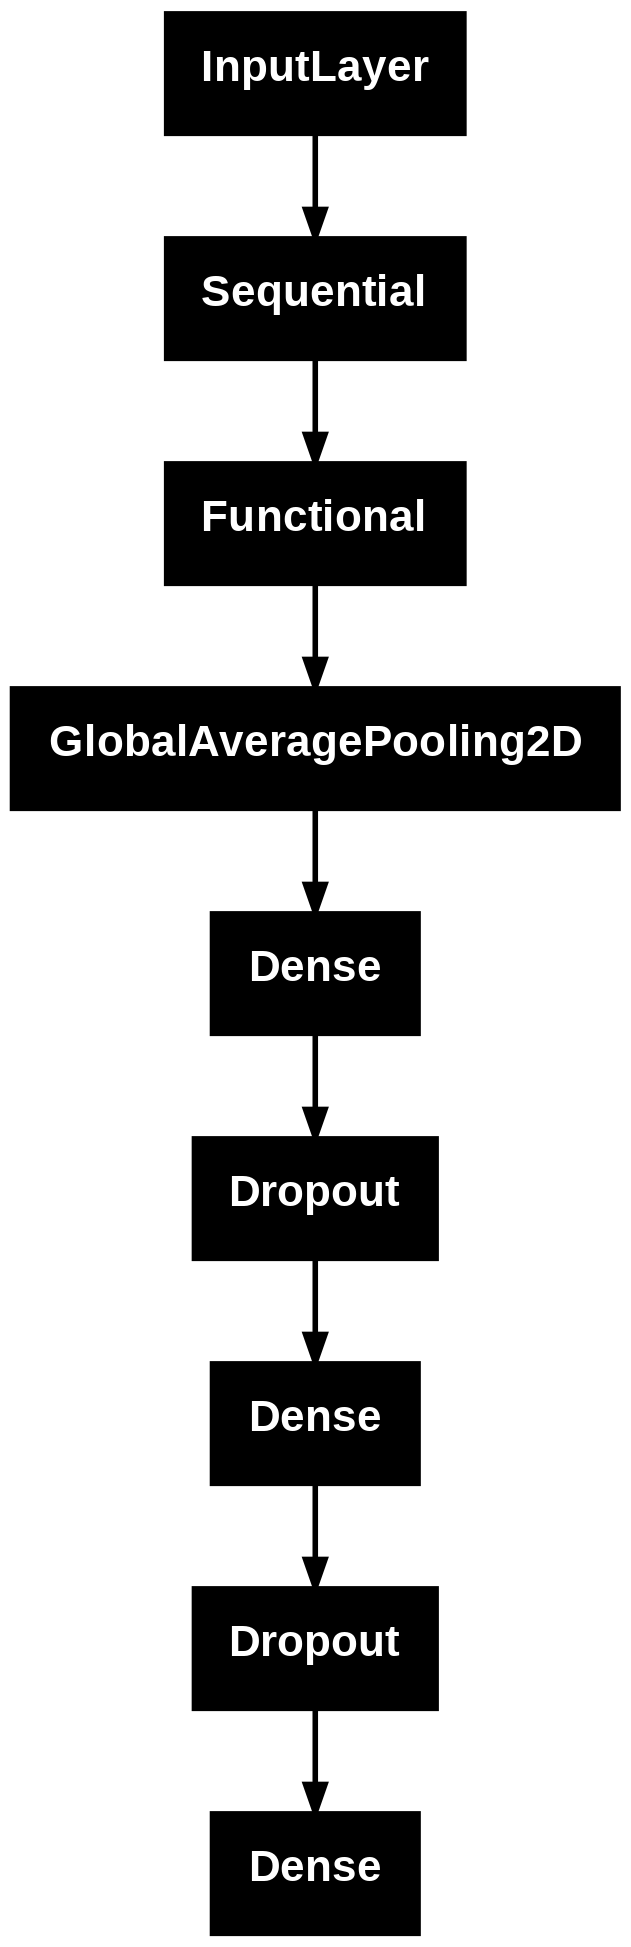

In [41]:
from keras.utils import plot_model
plot_model(model)

In [42]:
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 14,720,769 (56.16 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

In [43]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [45]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # lower LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=7,
    callbacks=[early_stop]
)

Epoch 1/7
163/163 ━━━━━━━━━━━━━━━━━━━━ 59s 277ms/step - accuracy: 0.7333 - loss: 0.5249 - val_accuracy: 0.6875 - val_loss: 0.5803
Epoch 2/7
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 270ms/step - accuracy: 0.9133 - loss: 0.2439 - val_accuracy: 0.6875 - val_loss: 0.5848
Epoch 3/7
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 265ms/step - accuracy: 0.9442 - loss: 0.1614 - val_accuracy: 0.6875 - val_loss: 0.4595
Epoch 4/7
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 272ms/step - accuracy: 0.9565 - loss: 0.1287 - val_accuracy: 0.9375 - val_loss: 0.3262
Epoch 5/7
163/163 ━━━━━━━━━━━━━━━━━━━━ 81s 265ms/step - accuracy: 0.9641 - loss: 0.1072 - val_accuracy: 0.9375 - val_loss: 0.2184
Epoch 6/7
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 273ms/step - accuracy: 0.9720 - loss: 0.0912 - val_accuracy: 0.9375 - val_loss: 0.2022
Epoch 7/7
163/163 ━━━━━━━━━━━━━━━━━━━━ 80s 264ms/step - accuracy: 0.9718 - loss: 0.0838 - val_accuracy: 0.9375 - val_loss: 0.1290


In [47]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for x, y in test_ds:
    preds = model.predict(x)
    y_true.extend(y.numpy())
    y_pred.extend((preds > 0.7).astype(int))

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
              precision    recall  f1-score   support

           0       0.96      0.69      0.80       234
           1       0.84      0.98      0.91       390

    accuracy                           0.87       624
  

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step
Prediction: PNEUMONIA
Confidence: 0.997


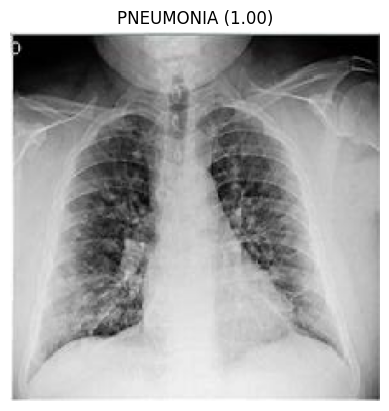

In [50]:
from tensorflow.keras.preprocessing import image
import numpy as np
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt


img_path = '/content/x_ray.jpg'


img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)


pred = model.predict(img_array)
confidence = float(pred[0][0])


result = "PNEUMONIA" if confidence > 0.7 else "NORMAL"

print("Prediction:", result)
print("Confidence:", round(confidence, 3))

plt.imshow(img)
plt.title(f"{result} ({confidence:.2f})")
plt.axis("off")
plt.show()